   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
(918, 12)
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak          

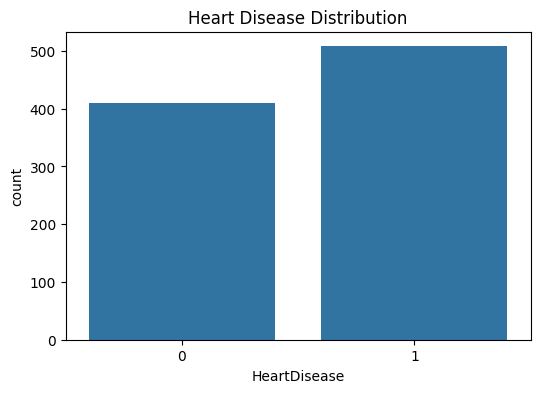

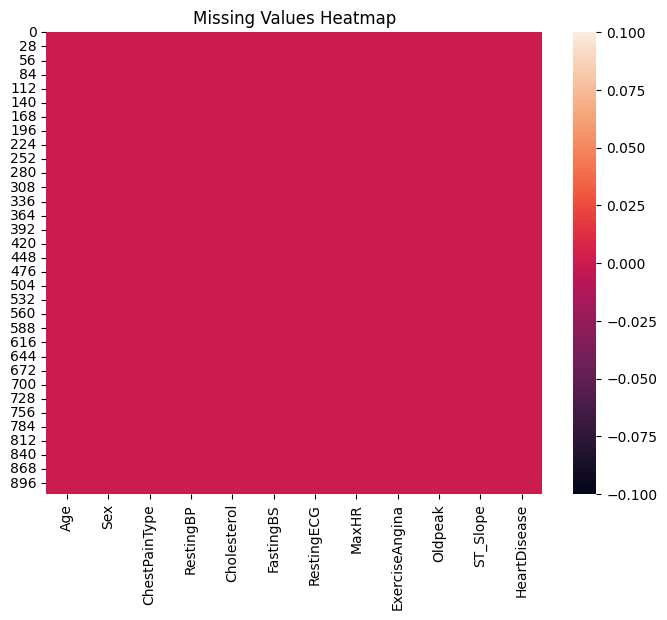

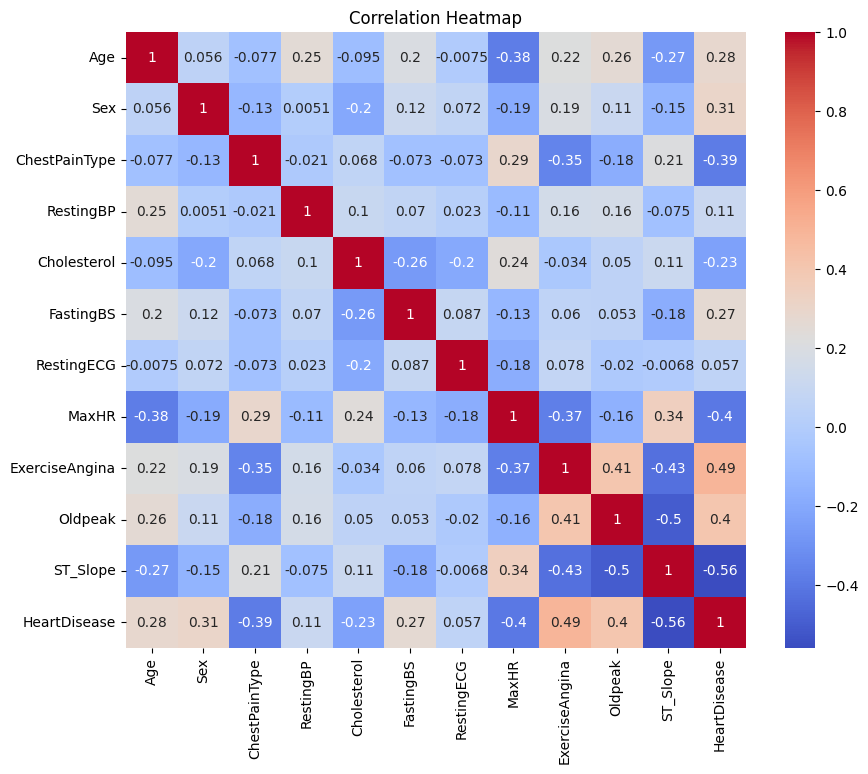

In [2]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("heart_failure_predition.csv")

print(df.head())
print(df.shape)

# ==========================================
# CHECK MISSING VALUES
# ==========================================

print(df.isnull().sum())

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ==========================================
# EDA VISUALIZATIONS
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=True)
plt.title("Missing Values Heatmap")
plt.show()

# ==========================================
# LABEL ENCODING
# ==========================================

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# FEATURES & TARGET
# ==========================================

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# ==========================================
# FEATURE SCALING
# ==========================================

scaler = RobustScaler()

X = scaler.fit_transform(X)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# LOGISTIC REGRESSION
# ==========================================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

# ==========================================
# RANDOM FOREST
# ==========================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

# ==========================================
# BAGGING
# ==========================================

bagging = BaggingClassifier(
    estimator=RandomForestClassifier(),
    n_estimators=10,
    random_state=42
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)

bag_acc = accuracy_score(y_test, bag_pred)

# ==========================================
# VOTING CLASSIFIER
# ==========================================

voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('bag', bagging)
    ],
    voting='hard'
)

voting.fit(X_train, y_train)

vote_pred = voting.predict(X_test)

vote_acc = accuracy_score(y_test, vote_pred)

In [10]:
lr_t_acc = lr.score(X_train, y_train)
lr_t_acc = lr.score(X_test, y_test)

print("Train Accuracy:", lr_t_acc)
print("Test Accuracy:", lr_t_acc)

rf_t_acc = rf.score(X_train, y_train)
rf_t_acc = rf.score(X_test, y_test)

print("Train Accuracy:", rf_t_acc)
print("Test Accuracy:", rf_t_acc)

bag_t_acc = bagging.score(X_train, y_train)
bag_t_acc = bagging.score(X_test, y_test)

print("Train Accuracy:", bag_t_acc)
print("Test Accuracy:", bag_t_acc)

Train Accuracy: 0.8695652173913043
Test Accuracy: 0.8695652173913043
Train Accuracy: 0.8913043478260869
Test Accuracy: 0.8913043478260869
Train Accuracy: 0.8913043478260869
Test Accuracy: 0.8913043478260869



Model Accuracy

Logistic Regression : 0.8696
Random Forest       : 0.8913
Bagging             : 0.8913
Voting              : 0.9022


Text(0, 0.5, 'Accuracy')

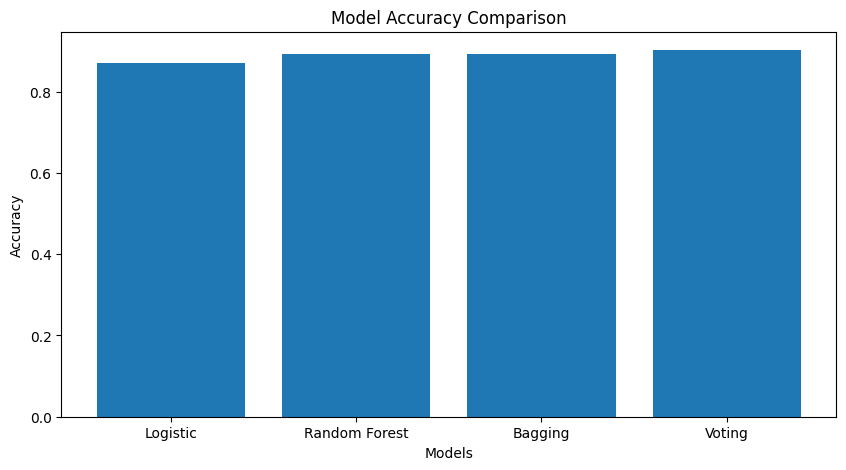

In [4]:
# ==========================================
# ACCURACY RESULTS
# ==========================================

print("\nModel Accuracy\n")

print("Logistic Regression :", round(lr_acc,4))
print("Random Forest       :", round(rf_acc,4))
print("Bagging             :", round(bag_acc,4))
print("Voting              :", round(vote_acc,4))

# ==========================================
# ACCURACY COMPARISON GRAPH
# ==========================================

models = [
    'Logistic',
    'Random Forest',
    'Bagging',
    'Voting'
]

scores = [
    lr_acc,
    rf_acc,
    bag_acc,
    vote_acc
]

plt.figure(figsize=(10,5))

bars = plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center'
    )

plt.ylim(0,1)
plt.show()

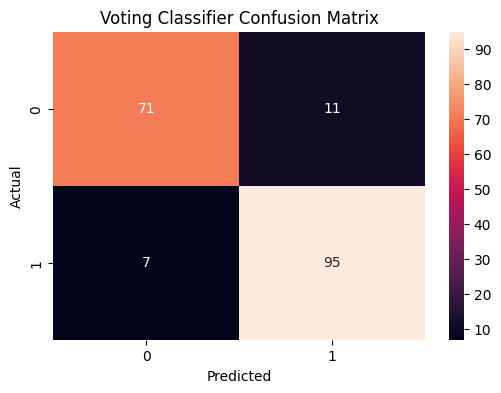

In [5]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, vote_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Voting Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [6]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report\n")

print(classification_report(y_test, vote_pred))


Classification Report

              precision    recall  f1-score   support

           0       0.91      0.87      0.89        82
           1       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



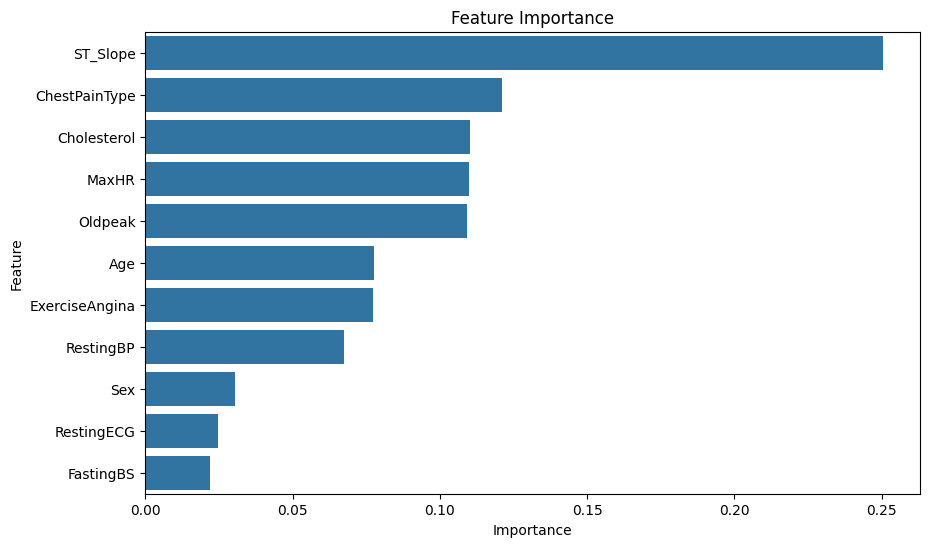

In [7]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = rf.feature_importances_

feature_names = df.drop(
    'HeartDisease',
    axis=1
).columns

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

imp_df = imp_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=imp_df,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()